# Mean-centred analysis of volume source data

This example demonstrates how we can analyze source time courses in a volumetric source space.

## Loading data

We will begin by loading the sample data and extracting epochs corresponding to auditory stimuli presented to the left versus right ear.

In [32]:
import mne
from mne.datasets import sample
from mne.minimum_norm import apply_inverse, apply_inverse_epochs, read_inverse_operator
import mne_plsc

data_path = sample.data_path()
meg_path = data_path / "MEG" / "sample"
fname_raw = meg_path / "sample_audvis_filt-0-40_raw.fif"
fname_event = meg_path / "sample_audvis_filt-0-40_raw-eve.fif"

# Load data
raw = mne.io.read_raw_fif(fname_raw)
events = mne.read_events(fname_event)

# Add a bad channel
raw.info["bads"] += ["EEG 053"]  # bads + 1 more

# pick MEG channels
picks = mne.pick_types(
    raw.info, meg=True, eeg=False, stim=False, eog=True, exclude="bads"
)
# Read epochs
epochs = mne.Epochs(
    raw,
    events,
    event_id={'left': 1, 'right': 2},
    tmin=-0.2, tmax=0.5,
    picks=picks,
    baseline=(None, 0),
    reject=dict(mag=4e-12, grad=4000e-13, eog=150e-6),
    preload=True,
    verbose=False
)
# Crop to a small window for speed
epochs = epochs.crop(tmin=0.05, tmax=0.1)

Opening raw data file C:\Users\isaac\mne_data\MNE-sample-data\MEG\sample\sample_audvis_filt-0-40_raw.fif...
    Read a total of 4 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
        Average EEG reference (1 x 60)  idle
    Range : 6450 ... 48149 =     42.956 ...   320.665 secs
Ready.


## Computing volume source estimate

Next, we will load the pre-computed inverse operator for the sample dataset and apply it to the epochs. This yields a list of source time courses (STCs).

In [11]:
fname_inv = meg_path / "sample_audvis-meg-vol-7-meg-inv.fif"
inverse_operator = read_inverse_operator(fname_inv, verbose=False)

snr = 3.0
lambda2 = 1.0 / snr**2
stcs = apply_inverse_epochs(
    epochs=epochs,
    inverse_operator=inverse_operator,
    lambda2=lambda2,
    method='dSPM',
    verbose=False
)

## Fitting mean-centred PLS model

Next, we will get the labels for the epochs and fit a mean-centred PLS model.

In [18]:
labels = mne_plsc.utils.get_epoch_labels(epochs)
res = mne_plsc.fit_mc(stcs,
                      between=labels,
                      random_state=123)

## Assessing model significance

We can assess the significance of the model using permutation testing. We will do a small number of permutations here for speed, but for real data it would be best to do many more.

In [19]:
res.permute(100)
print(res.summary())

Permuting: 100%|██████████████████████████████████████████████████████████████████████████████████| 100/100 [00:01<00:00, 53.56it/s]

   LV index  singular value  variance explained   p value
0         0       22.784547                 1.0  0.009901
1         1        0.000000                 0.0       NaN


## Cluster analysis

To characterize the pattern that differentiates the two conditions, we can perform cluster analysis. First, we will perform bootstrap resampling to estimate the $z$ scores of the brain saliences.

In [25]:
res.bootstrap(100)

Resampling: 100%|█████████████████████████████████████████████████████████████████████████████████| 100/100 [00:03<00:00, 28.87it/s]


Next, we will add information about the source space. for a volumetric source space, this means adding both the `VolSourceSpaces` object corresponding to the inverse operator and the structural data.

In [22]:
res.add_source_info(src=inverse_operator['src'],
                    t1=data_path / "subjects" / "sample" / "mri" / "T1.mgz")

Next, we can add an adjacency matrix and compute clusters. As the plot below shows, there are two major clusters in the data.

-- number of adjacent vertices : 3757
Clustering z-scores
Defaulting to unsigned clustering
Computing clusters for lv_idx 0...
57 clusters


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Cluster index', ylabel='Cluster size (% of strong saliences)'>)

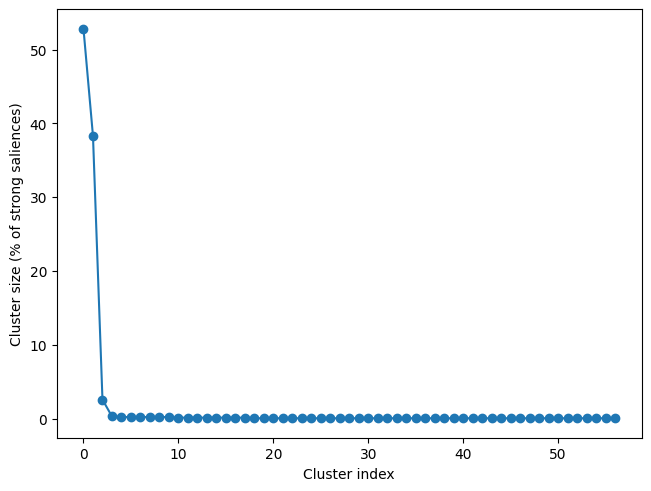

In [31]:
res.add_adjacency()
res.cluster(threshold=3)
res.plot_cluster_sizes(lv_idx=0)

Visualizing the clusters, we can see that they overlap with the left and right auditory cortex, respectively.

C:\Users\isaac\Projects\mne-plsc\src\mne_plsc\viz.py:472: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  plotting.plot_stat_map(vol,
C:\Users\isaac\Projects\mne-plsc\src\mne_plsc\viz.py:472: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  plotting.plot_stat_map(vol,


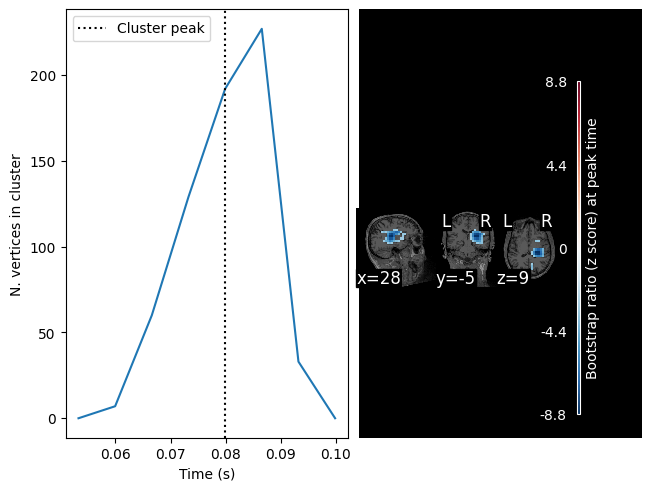

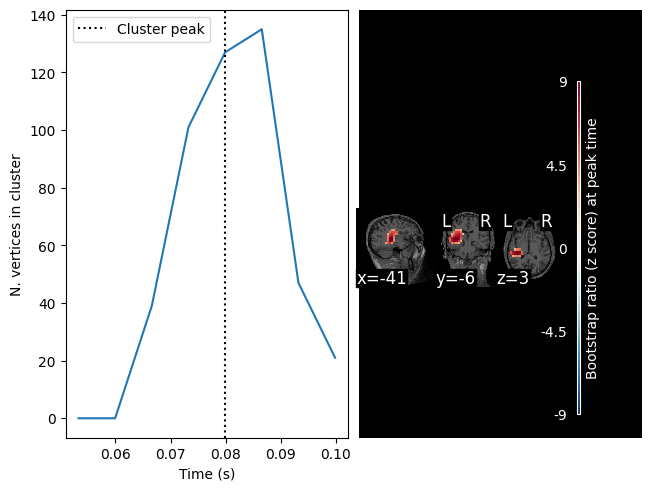

In [30]:
res.plot_cluster(lv_idx=0, cluster_idx=0)
res.plot_cluster(lv_idx=0, cluster_idx=1)